<a href="https://colab.research.google.com/github/arsy25/ASHARAN-INVOICE-GENERATOR/blob/main/UAS_COMPVIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  GPU tidak terdeteksi! Aktifkan dulu via Runtime → Change runtime type → T4 GPU')

!nvidia-smi

In [ ]:
!pip install ultralytics roboflow -q

# Verifikasi instalasi
import ultralytics
ultralytics.checks()
print('\n✅ Semua dependencies berhasil diinstall!')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)

✅ Semua dependencies berhasil diinstall!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Buat folder project di Drive
PROJECT_DRIVE = '/content/drive/MyDrive/UAS - COMPVISION - DATASET'
os.makedirs(PROJECT_DRIVE, exist_ok=True)
os.makedirs(f'{PROJECT_DRIVE}/models', exist_ok=True)
os.makedirs(f'{PROJECT_DRIVE}/results', exist_ok=True)

print(f'✅ Google Drive terhubung!')
print(f'📁 Folder project: {PROJECT_DRIVE}')

Mounted at /content/drive
✅ Google Drive terhubung!
📁 Folder project: /content/drive/MyDrive/UAS - COMPVISION - DATASET


In [ ]:
import os

# ============================================================
#  ⚙️  EDIT BAGIAN INI — Sesuaikan nama folder dataset kamu
# ============================================================
DATASET_FOLDER = 'UAS - COMPVISION - DATASET'  # ← Ganti dengan nama folder dataset di Drive
# ============================================================

DATASET_PATH = f'/content/drive/MyDrive/{DATASET_FOLDER}'
yaml_path    = os.path.join(DATASET_PATH, 'data.yaml')

# Validasi struktur folder
assert os.path.exists(DATASET_PATH), f'❌ Folder tidak ditemukan: {DATASET_PATH}'
assert os.path.exists(yaml_path),    f'❌ data.yaml tidak ditemukan di: {DATASET_PATH}'

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    n_imgs  = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(img_dir) else 0
    n_lbls  = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')]) if os.path.exists(lbl_dir) else 0
    status  = '✅' if n_imgs > 0 else '⚠️ '
    print(f'{status} {split:<6} → {n_imgs:>4} gambar | {n_lbls:>4} label')

print(f'\n✅ Dataset ditemukan di: {DATASET_PATH}')
print(f'📄 data.yaml  : {yaml_path}')

# Tampilkan isi data.yaml
import yaml
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
print('\n📋 Isi data.yaml:')
for k, v in data_config.items():
    print(f'   {k}: {v}')

✅ train  → 5580 gambar | 5580 label
✅ valid  →  578 gambar |  578 label
✅ test   →  228 gambar |  228 label

✅ Dataset ditemukan di: /content/drive/MyDrive/UAS - COMPVISION - DATASET
📄 data.yaml  : /content/drive/MyDrive/UAS - COMPVISION - DATASET/data.yaml

📋 Isi data.yaml:
   train: ../train/images
   val: ../valid/images
   test: ../test/images
   nc: 1
   names: ['Fire detection - v2 2024-09-18 4-14am -X-']
   roboflow: {'workspace': 'sean-cftrp', 'project': 'fire-z2n21', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/sean-cftrp/fire-z2n21/dataset/1'}


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random

# --- Hitung jumlah gambar ---
train_img_path = os.path.join(DATASET_PATH, 'train', 'images')
val_img_path   = os.path.join(DATASET_PATH, 'valid', 'images')  # atau 'val'

# Handle nama folder val yang berbeda (valid vs val)
if not os.path.exists(val_img_path):
    val_img_path = os.path.join(DATASET_PATH, 'val', 'images')

train_imgs = [f for f in os.listdir(train_img_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
val_imgs   = [f for f in os.listdir(val_img_path)   if f.lower().endswith(('.jpg','.jpeg','.png'))]

print('='*50)
print('📊 STATISTIK DATASET')
print('='*50)
print(f'Training images  : {len(train_imgs)}')
print(f'Validation images: {len(val_imgs)}')
print(f'Total            : {len(train_imgs) + len(val_imgs)}')
print('='*50)

📊 STATISTIK DATASET
Training images  : 5580
Validation images: 578
Total            : 6158


Kelas yang terdeteksi: ['Fire detection - v2 2024-09-18 4-14am -X-']


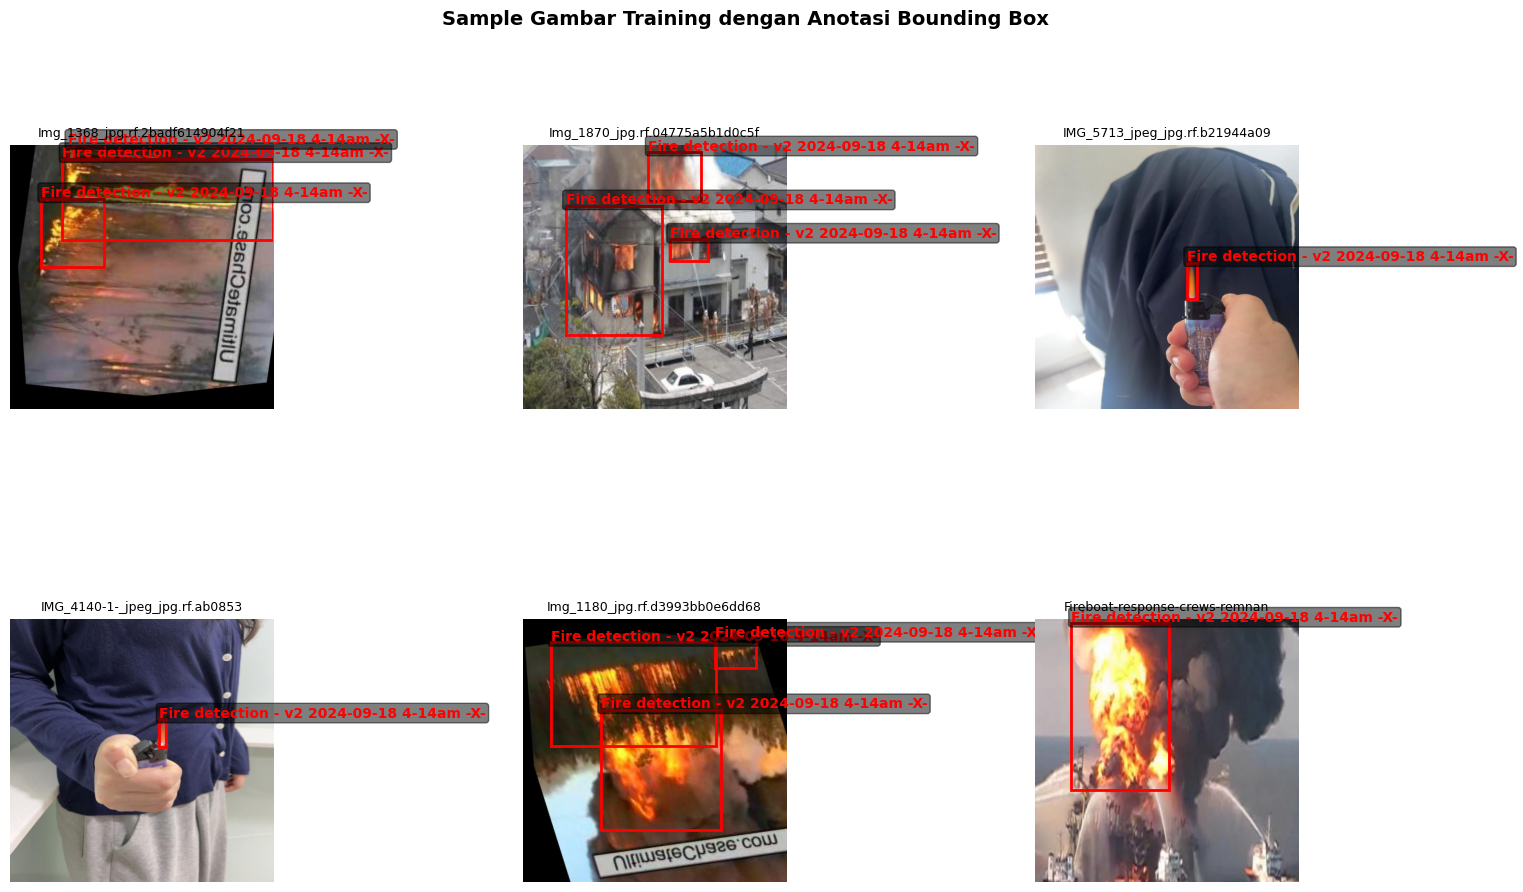

✅ Gambar sample berhasil divisualisasikan!


In [ ]:
# --- Visualisasi sample gambar dengan bounding box ---
def yolo_to_pixel(bbox, img_w, img_h):
    """Konversi koordinat YOLO (normalized) ke pixel."""
    cx, cy, bw, bh = bbox
    x1 = (cx - bw/2) * img_w
    y1 = (cy - bh/2) * img_h
    return x1, y1, bw * img_w, bh * img_h

# Warna per kelas
CLASS_COLORS = ['red', 'orange', 'yellow', 'blue', 'green']

# Baca nama kelas dari data.yaml
import yaml
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', ['fire', 'smoke'])
print(f'Kelas yang terdeteksi: {class_names}')

# Tampilkan 6 gambar sample
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

for idx, img_name in enumerate(sample_imgs):
    img_path   = os.path.join(train_img_path, img_name)
    label_path = os.path.join(DATASET_PATH, 'train', 'labels',
                              img_name.rsplit('.', 1)[0] + '.txt')

    img = Image.open(img_path).convert('RGB')
    img_w, img_h = img.size

    axes[idx].imshow(img)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    bbox   = list(map(float, parts[1:]))
                    x, y, w, h = yolo_to_pixel(bbox, img_w, img_h)
                    color = CLASS_COLORS[cls_id % len(CLASS_COLORS)]
                    rect = patches.Rectangle((x, y), w, h,
                                             linewidth=2, edgecolor=color, facecolor='none')
                    axes[idx].add_patch(rect)
                    label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                    axes[idx].text(x, y-5, label, color=color,
                                  fontsize=10, fontweight='bold',
                                  bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

    axes[idx].axis('off')
    axes[idx].set_title(img_name[:30], fontsize=9)

plt.suptitle('Sample Gambar Training dengan Anotasi Bounding Box', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_DRIVE}/results/sample_annotations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar sample berhasil divisualisasikan!')

In [ ]:
import yaml, os

# Baca isi data.yaml yang sudah ada
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

print('📄 Isi data.yaml sebelum diupdate:')
for k, v in config.items():
    print(f'  {k}: {v}')

# Update path absolut agar YOLOv8 bisa menemukan dataset di Colab
config['path']  = DATASET_PATH
config['train'] = 'train/images'
config['val']   = 'valid/images'
config['test']  = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print('\n✅ data.yaml berhasil diupdate dengan path absolut!')
print(f'   path : {DATASET_PATH}')
print(f'   nc   : {config["nc"]}')
print(f'   names: {config["names"]}')

📄 Isi data.yaml sebelum diupdate:
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 1
  names: ['Fire detection - v2 2024-09-18 4-14am -X-']
  roboflow: {'workspace': 'sean-cftrp', 'project': 'fire-z2n21', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/sean-cftrp/fire-z2n21/dataset/1'}

✅ data.yaml berhasil diupdate dengan path absolut!
   path : /content/drive/MyDrive/UAS - COMPVISION - DATASET
   nc   : 1
   names: ['Fire detection - v2 2024-09-18 4-14am -X-']


In [ ]:
import os

DATASET_PATH = '/content/drive/MyDrive/UAS - COMPVISION - DATASET'

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_PATH, split, 'images')
    lbl_dir = os.path.join(DATASET_PATH, split, 'labels')
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0

    # Cek label kosong (file .txt yang isinya kosong)
    empty_labels = 0
    if os.path.exists(lbl_dir):
        for f in os.listdir(lbl_dir):
            if f.endswith('.txt'):
                if os.path.getsize(os.path.join(lbl_dir, f)) == 0:
                    empty_labels += 1

    print(f'{split}: {imgs} gambar | {lbls} label | {empty_labels} label kosong ⚠️')

train: 5580 gambar | 5580 label | 0 label kosong ⚠️
valid: 578 gambar | 578 label | 0 label kosong ⚠️
test: 228 gambar | 228 label | 0 label kosong ⚠️


In [ ]:
from ultralytics import YOLO

# Load model YOLOv8n (pretrained on COCO)
model = YOLO('yolov8n.pt')  # Akan otomatis download weights pretrained

# ============================================================
#  KONFIGURASI TRAINING — Edit sesuai kebutuhan
# ============================================================
EPOCHS    = 50    # Tambah ke 100 untuk akurasi lebih tinggi
IMG_SIZE  = 640
BATCH     = 16    # Turunkan ke 8 jika muncul error CUDA Out of Memory
PATIENCE  = 15    # Early stopping
PROJECT   = PROJECT_DRIVE + '/models'
RUN_NAME  = 'fire_smoke_yolov8n_v1'
# ============================================================

print('🚀 Memulai Training YOLOv8n...')
print(f'   Model   : YOLOv8n')
print(f'   Epochs  : {EPOCHS}')
print(f'   Img Size: {IMG_SIZE}')
print(f'   Batch   : {BATCH}')
print(f'   Dataset : {yaml_path}')
print(f'   Output  : {PROJECT}/{RUN_NAME}')
print('-'*50)

results = model.train(
    data     = yaml_path,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    patience = PATIENCE,
    device   = 0,         # GPU
    project  = PROJECT,
    name     = RUN_NAME,
    exist_ok = True,

    # Data Augmentation (sudah aktif by default, ini untuk kustomisasi)
    hsv_h    = 0.015,     # Augmentasi warna (penting untuk deteksi api)
    hsv_s    = 0.7,
    hsv_v    = 0.4,
    flipud   = 0.0,       # Flip vertikal (matikan untuk indoor)
    fliplr   = 0.5,       # Flip horizontal
    mosaic   = 1.0,       # Mosaic augmentation
    mixup    = 0.1,       # Mixup augmentation

    # Hyperparameter
    lr0      = 0.01,      # Learning rate awal
    lrf      = 0.01,      # Learning rate akhir (lr0 * lrf)
    weight_decay = 0.0005,

    # Logging
    save     = True,
    save_period = 10,     # Simpan checkpoint setiap 10 epoch
    verbose  = True,
)

print('\n✅ Training selesai!')

🚀 Memulai Training YOLOv8n...
   Model   : YOLOv8n
   Epochs  : 50
   Img Size: 640
   Batch   : 16
   Dataset : /content/drive/MyDrive/UAS - COMPVISION - DATASET/data.yaml
   Output  : /content/drive/MyDrive/UAS - COMPVISION - DATASET/models/fire_smoke_yolov8n_v1
--------------------------------------------------
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/UAS - COMPVISION - DATASET/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h

In [ ]:
import os

# Path hasil training
TRAIN_OUTPUT = f'{PROJECT}/{RUN_NAME}'
BEST_MODEL   = f'{TRAIN_OUTPUT}/weights/best.pt'

print(f'📁 Folder hasil training : {TRAIN_OUTPUT}')
print(f'🏆 Model terbaik (best.pt): {BEST_MODEL}')
print(f'\nFile yang dihasilkan:')

# Gunakan os.listdir() agar aman dari masalah spasi di path
weights_dir = f'{TRAIN_OUTPUT}/weights'
if os.path.exists(weights_dir):
    for f in os.listdir(weights_dir):
        size_mb = os.path.getsize(os.path.join(weights_dir, f)) / 1e6
        print(f'  {f}  ({size_mb:.1f} MB)')
else:
    print(f'❌ Folder weights tidak ditemukan: {weights_dir}')

# Cek file PNG
png_files = [f for f in os.listdir(TRAIN_OUTPUT) if f.endswith('.png')]
if png_files:
    for f in png_files:
        print(f'  📊 {f}')
else:
    print('(tidak ada file PNG langsung)')

📁 Folder hasil training : /content/drive/MyDrive/UAS - COMPVISION - DATASET/models/fire_smoke_yolov8n_v1
🏆 Model terbaik (best.pt): /content/drive/MyDrive/UAS - COMPVISION - DATASET/models/fire_smoke_yolov8n_v1/weights/best.pt

File yang dihasilkan:
  last.pt  (6.2 MB)
  best.pt  (6.2 MB)
  epoch0.pt  (24.5 MB)
  epoch10.pt  (24.5 MB)
  epoch20.pt  (24.5 MB)
  epoch30.pt  (24.5 MB)
  epoch40.pt  (24.5 MB)
  📊 BoxPR_curve.png
  📊 BoxF1_curve.png
  📊 BoxP_curve.png
  📊 BoxR_curve.png
  📊 confusion_matrix_normalized.png
  📊 confusion_matrix.png
  📊 results.png


📊 Kolom yang tersedia di results.csv:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Total epoch yang dijalankan: 50

5 epoch terakhir:
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
45     46  5746.03         1.47681         0.98421         1.48487   
46     47  5861.34         1.46531         0.95447         1.46505   
47     48  5974.91         1.45025         0.94818         1.45552   
48     49  6090.69         1.43274         0.93089         1.44615   
49     50  6205.32         1.42773         0.91625         1.44096   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
45               0.85042            0.74154           0.83415   
46               0.87013            0.74905           0.84086   
47               0.84563            0.76000           0.

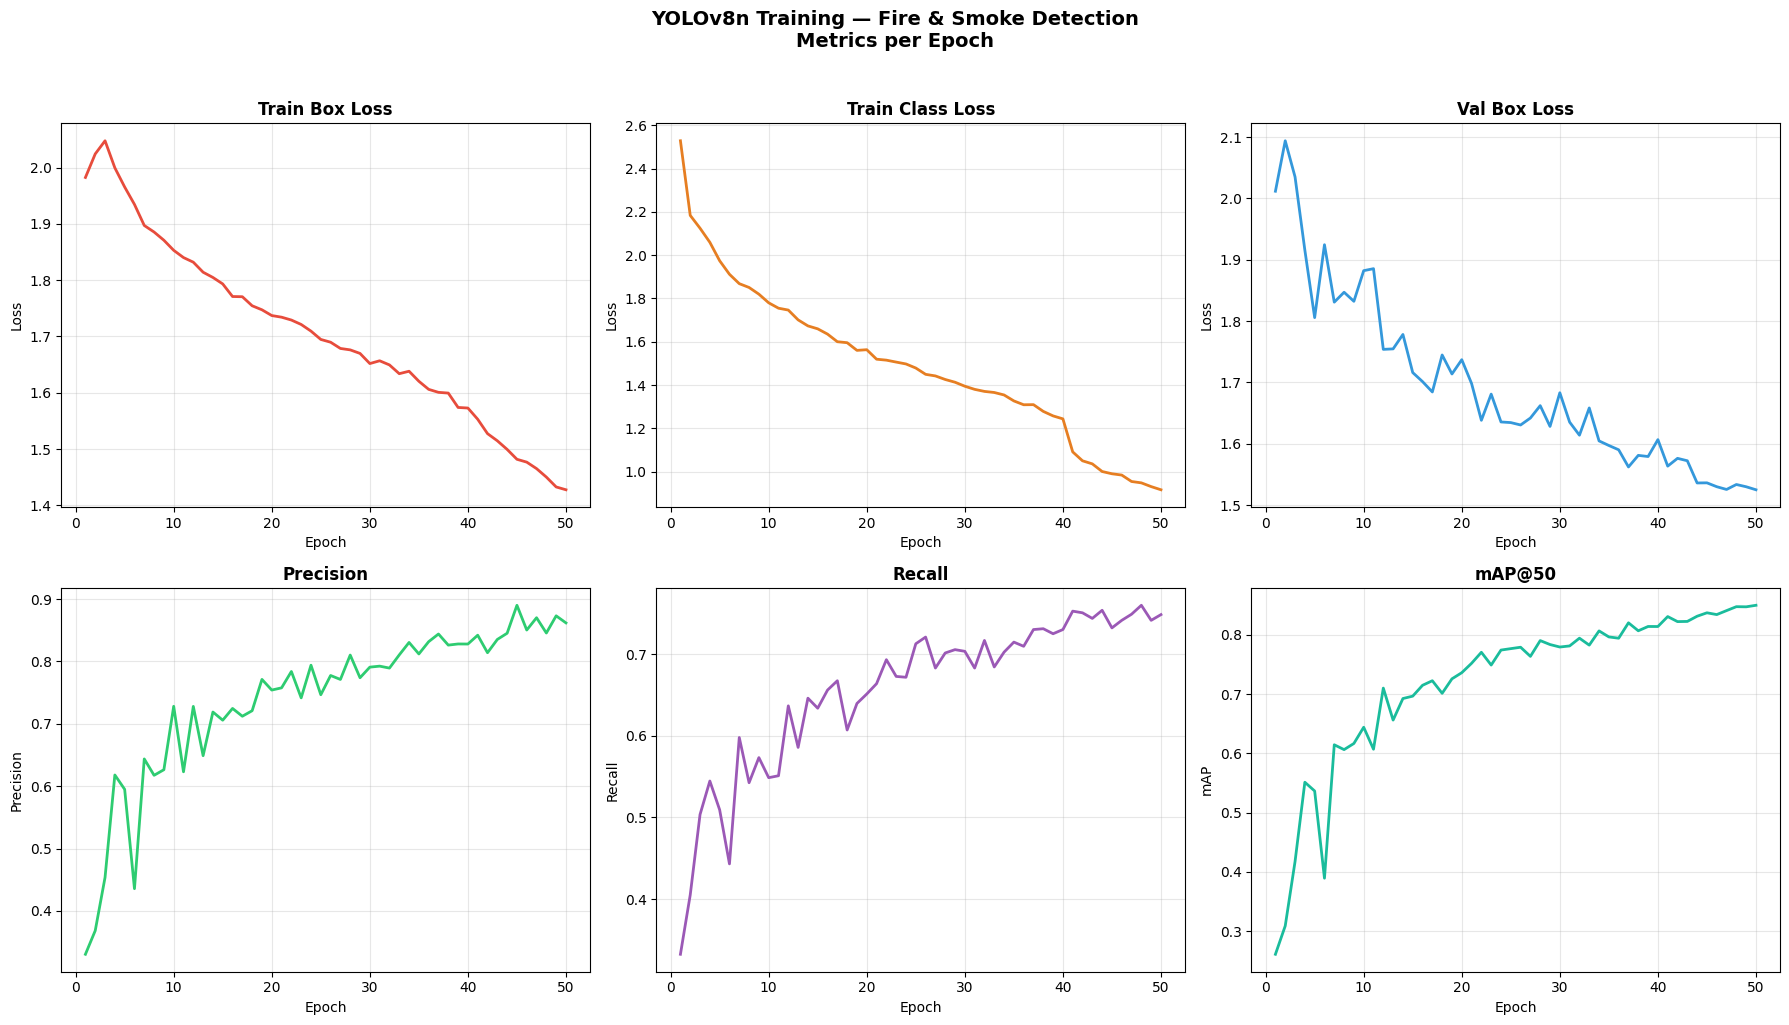

✅ Grafik disimpan ke: /content/drive/MyDrive/UAS - COMPVISION - DATASET/results/training_metrics.png
🏆 METRIK AKHIR TRAINING
  Precision   : [█████████████████░░░] 0.8618
  Recall      : [██████████████░░░░░░] 0.7486
  mAP@50      : [████████████████░░░░] 0.8498
  mAP@50-95   : [█████████░░░░░░░░░░░] 0.4704

📊 Confusion Matrix:


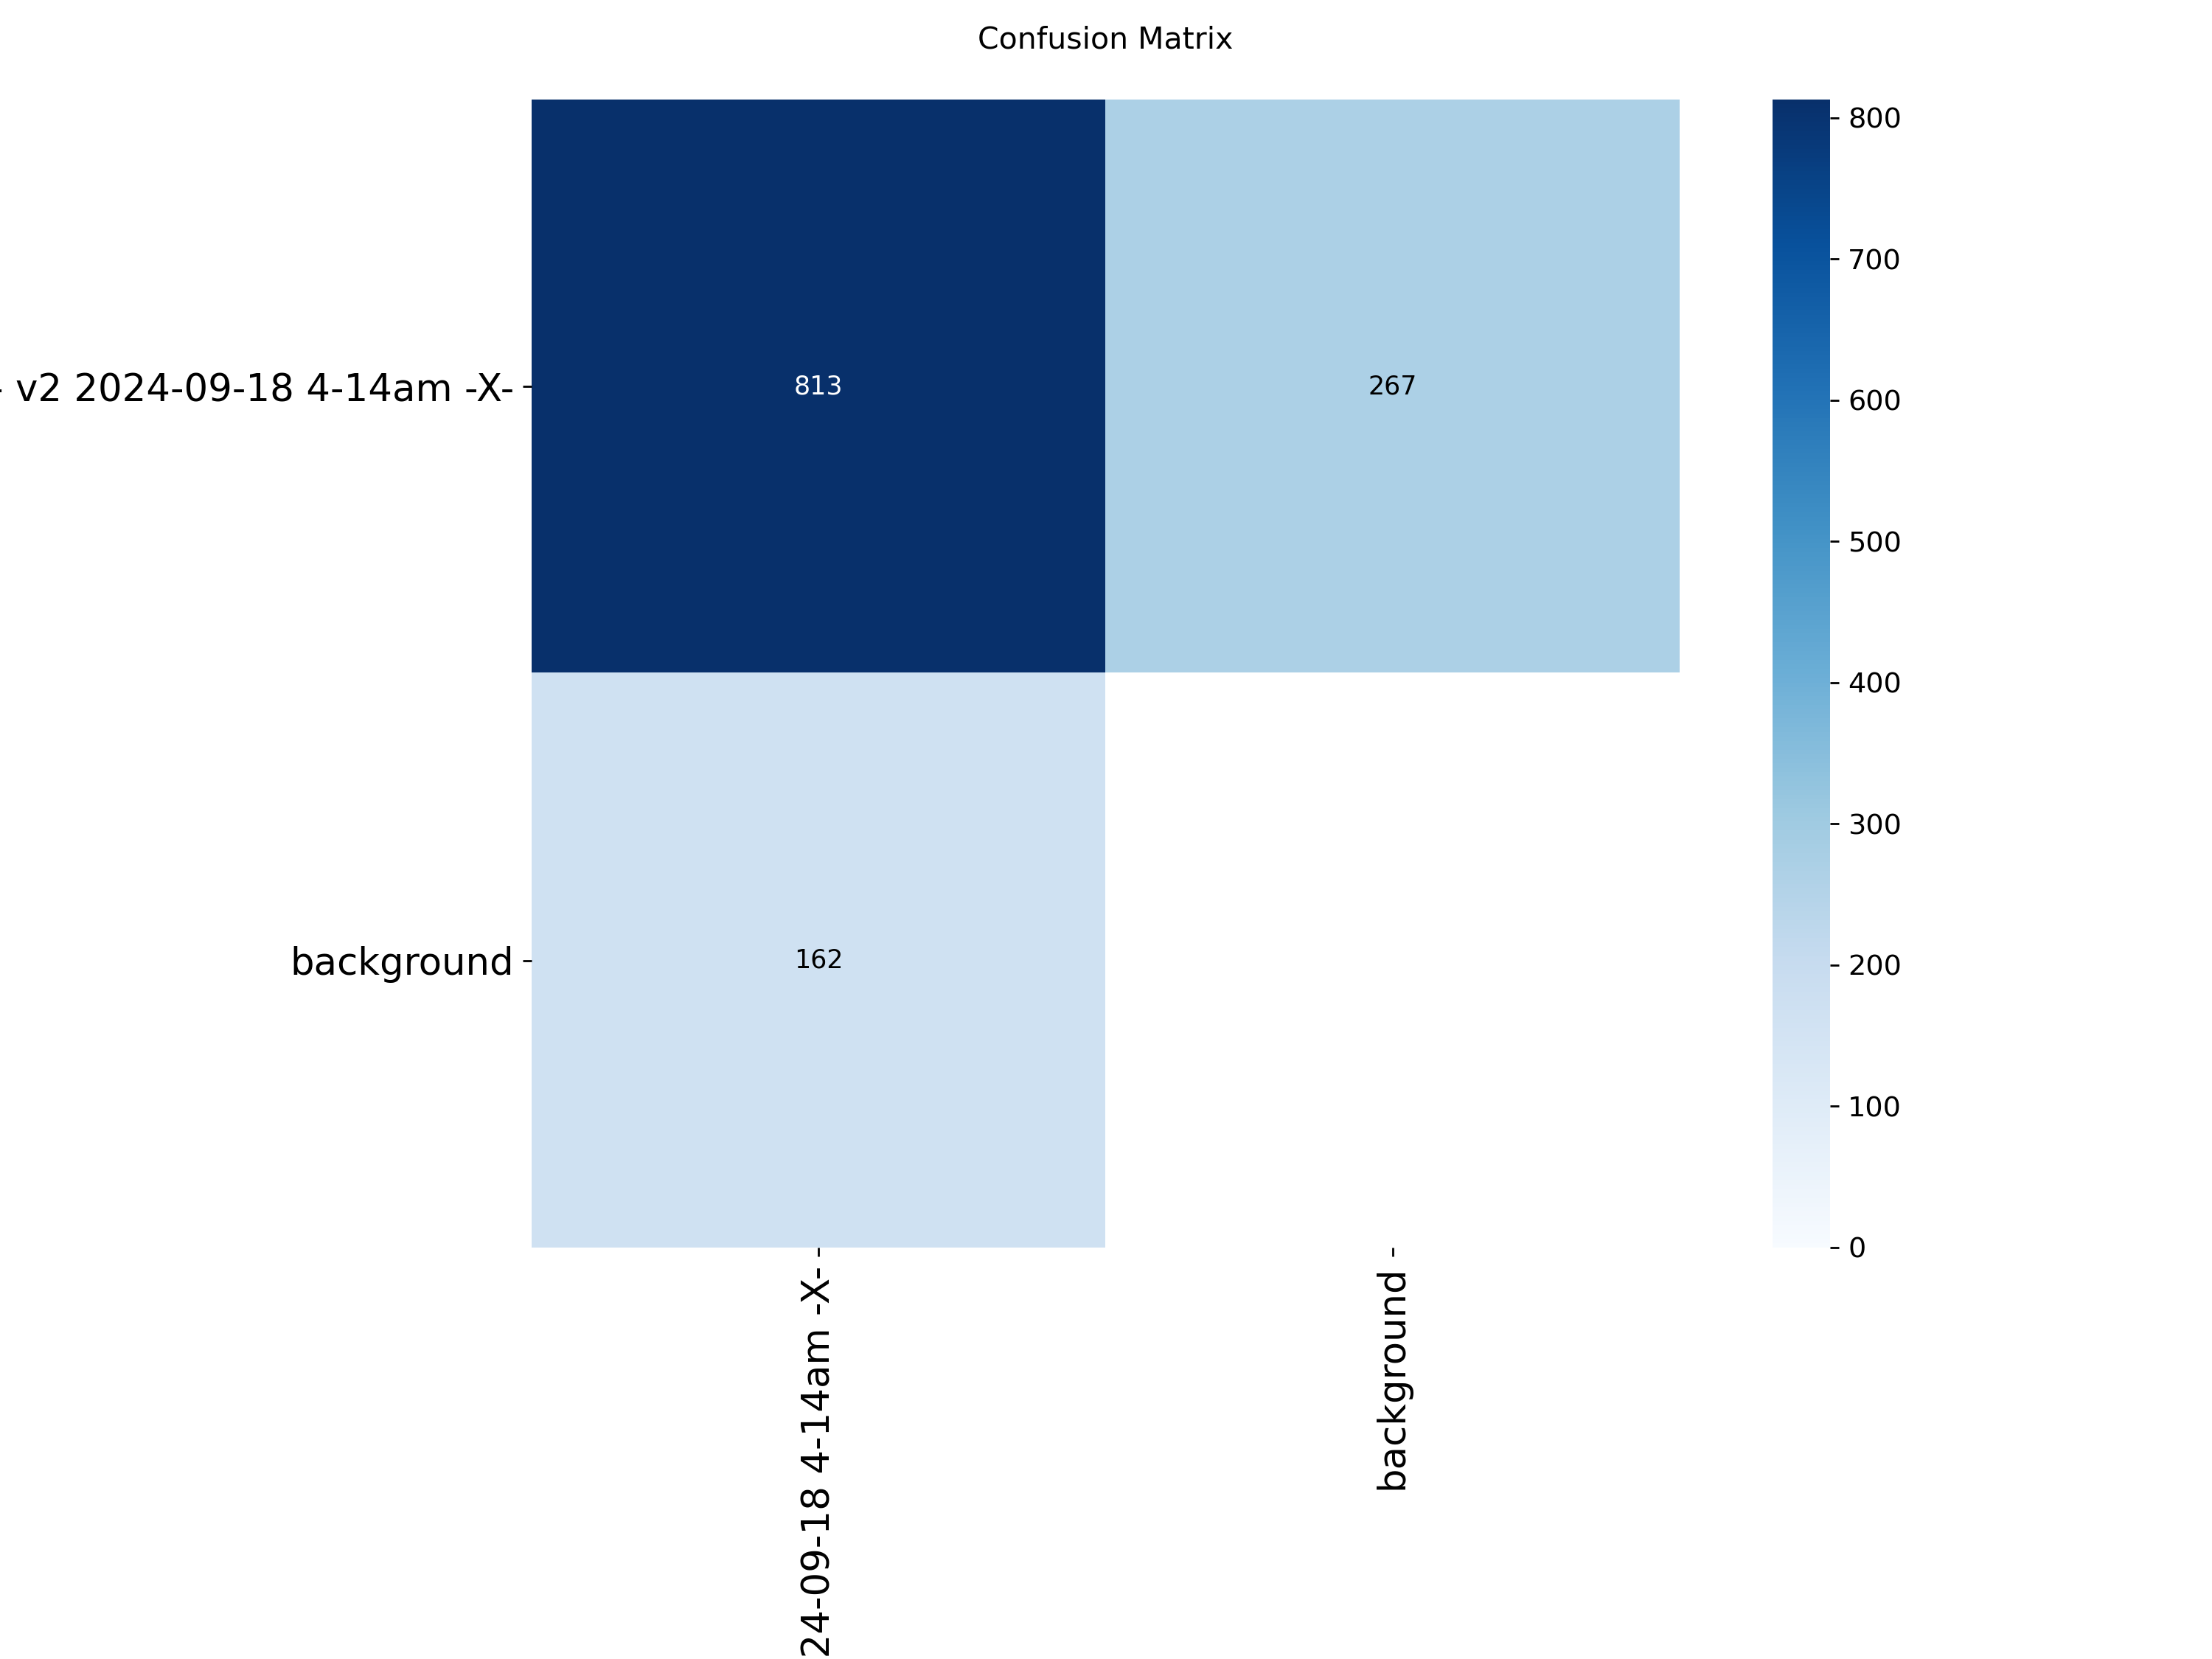

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca hasil training dari results.csv
results_csv = f'{TRAIN_OUTPUT}/results.csv'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()  # Hapus spasi di nama kolom

print('📊 Kolom yang tersedia di results.csv:')
print(df.columns.tolist())
print(f'\nTotal epoch yang dijalankan: {len(df)}')
print(f'\n5 epoch terakhir:')
print(df.tail())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Mapping nama kolom (Ultralytics bisa berubah antar versi)
col_map = {
    'train_box_loss' : [c for c in df.columns if 'train' in c and 'box' in c],
    'train_cls_loss' : [c for c in df.columns if 'train' in c and 'cls' in c],
    'val_box_loss'   : [c for c in df.columns if 'val' in c and 'box' in c],
    'val_cls_loss'   : [c for c in df.columns if 'val' in c and 'cls' in c],
    'precision'      : [c for c in df.columns if 'precision' in c.lower()],
    'recall'         : [c for c in df.columns if 'recall' in c.lower()],
    'mAP50'          : [c for c in df.columns if 'map50' in c.lower() and 'map50-95' not in c.lower()],
    'mAP50-95'       : [c for c in df.columns if 'map50-95' in c.lower()],
}

epochs = df['epoch'] if 'epoch' in df.columns else range(len(df))

def safe_plot(ax, col_key, title, ylabel, color='blue'):
    cols = col_map.get(col_key, [])
    if cols:
        ax.plot(epochs, df[cols[0]], color=color, linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

safe_plot(axes[0,0], 'train_box_loss', 'Train Box Loss',    'Loss',      '#e74c3c')
safe_plot(axes[0,1], 'train_cls_loss', 'Train Class Loss',  'Loss',      '#e67e22')
safe_plot(axes[0,2], 'val_box_loss',   'Val Box Loss',      'Loss',      '#3498db')
safe_plot(axes[1,0], 'precision',      'Precision',         'Precision', '#2ecc71')
safe_plot(axes[1,1], 'recall',         'Recall',            'Recall',    '#9b59b6')
safe_plot(axes[1,2], 'mAP50',          'mAP@50',            'mAP',       '#1abc9c')

plt.suptitle('YOLOv8n Training — Fire & Smoke Detection\nMetrics per Epoch',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plot_path = f'{PROJECT_DRIVE}/results/training_metrics.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Grafik disimpan ke: {plot_path}')

# Tampilkan metrik akhir
print('='*50)
print('🏆 METRIK AKHIR TRAINING')
print('='*50)

last = df.iloc[-1]
for col_key, label in [
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('mAP50',     'mAP@50'),
    ('mAP50-95',  'mAP@50-95'),
]:
    cols = col_map.get(col_key, [])
    if cols:
        val = last[cols[0]]
        bar_len = int(val * 20)
        bar = '█' * bar_len + '░' * (20 - bar_len)
        print(f'  {label:<12}: [{bar}] {val:.4f}')

print('='*50)

# Tampilkan confusion matrix jika tersedia
cm_path = f'{TRAIN_OUTPUT}/confusion_matrix.png'
if os.path.exists(cm_path):
    from IPython.display import Image as IPyImage, display
    print('\n📊 Confusion Matrix:')
    display(IPyImage(cm_path))

In [ ]:
from ultralytics import YOLO

# Load model terbaik
best_model = YOLO(BEST_MODEL)

# Validasi pada dataset validasi
print('📊 Menjalankan validasi pada dataset val...')
val_metrics = best_model.val(
    data   = yaml_path,
    imgsz  = IMG_SIZE,
    device = 0,
    conf   = 0.25,
    iou    = 0.5,
    verbose= True,
)

print(f'\n✅ Validasi selesai!')
print(f'   mAP@50    : {val_metrics.box.map50:.4f}')
print(f'   mAP@50-95 : {val_metrics.box.map:.4f}')
print(f'   Precision : {val_metrics.box.mp:.4f}')
print(f'   Recall    : {val_metrics.box.mr:.4f}')

ModuleNotFoundError: No module named 'ultralytics'